In [ ]:
#Dataset 3
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('Unicauca-dataset-April-June-2019-Network-flows.csv')

df.dropna(inplace=True)

df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.drop(['category'], axis=1, inplace=True)
df.drop(['application_protocol'], axis=1, inplace=True)
df.drop([ 'web_service'], axis=1, inplace=True)
df.drop([ 'flow_key'], axis=1, inplace=True)
df.drop(['src_ip'], axis=1, inplace=True)

destination_ip_frequency = df['dst_ip'].value_counts()
df['dst_ip'] = df['dst_ip'].map(destination_ip_frequency)

print(df.describe()) #to summarize statistics
print(df.info()) #to print info about dataset

train, test = train_test_split(df, test_size=0.2, shuffle=True)

       src_ip_numeric      src_port        dst_ip      dst_port         proto  \
count    1.672849e+06  1.672849e+06  1.672849e+06  1.672849e+06  1.672849e+06   
mean     3.232268e+09  5.109814e+04  1.456326e+05  2.101402e+03  1.076974e+01   
std      7.296518e+02  1.305275e+04  2.075411e+05  7.698215e+03  5.471581e+00   
min      3.232266e+09  0.000000e+00  1.000000e+00  0.000000e+00  1.000000e+00   
25%      3.232267e+09  4.976100e+04  3.800000e+02  5.300000e+01  6.000000e+00   
50%      3.232268e+09  5.314000e+04  7.580000e+03  4.430000e+02  6.000000e+00   
75%      3.232268e+09  5.872700e+04  4.732950e+05  4.430000e+02  1.700000e+01   
max      3.232269e+09  6.553500e+04  4.732950e+05  6.553500e+04  1.700000e+01   

       pktTotalCount  octetTotalCount        min_ps        max_ps  \
count   1.672849e+06     1.672849e+06  1.672849e+06  1.672849e+06   
mean    9.405460e+01     1.127839e+05  5.722136e+01  1.262567e+03   
std     3.942053e+03     5.703595e+06  5.968043e+01  2.933894e+

In [ ]:
# Dataset 3 DECISION TREE Minibatch K-Means
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans


k=9
batch_size =100
max_iter=200


minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

criterion_list = ['gini', 'entropy']
max_depth_list = [None, 10]
min_samples_split_list = [5, 10]
min_samples_leaf_list = [1, 2]
max_features_list = ['auto',  None]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)

    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):

        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklear

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

31


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklear

32


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None}
Best accuracy: 0.9999741912428902


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Decision Tree Classifier with Minibatch K-means cluster labels: 0.999960294456312
Precision: 0.9999603137327193
Recall: 0.999960294456312
F1-score: 0.9999602980487545
Confusion Matrix:
 [[23883     0     0     0     0     0     0     0     0]
 [    0 40420     0     0     5     0     0     0     0]
 [    0     0  1459     0     0     0     0     0     0]
 [    0     0     0  5881     0     0     0     0     0]
 [    0     0     0     0 10294     0     0     0     0]
 [    0     0     0     0     0   230     0     0     0]
 [    0     0     0     0     0     0 13046     0     0]
 [    0     0     0     0     0     0     0  6663     0]
 [    0     0     0     0     0     0     0     0 24046]]


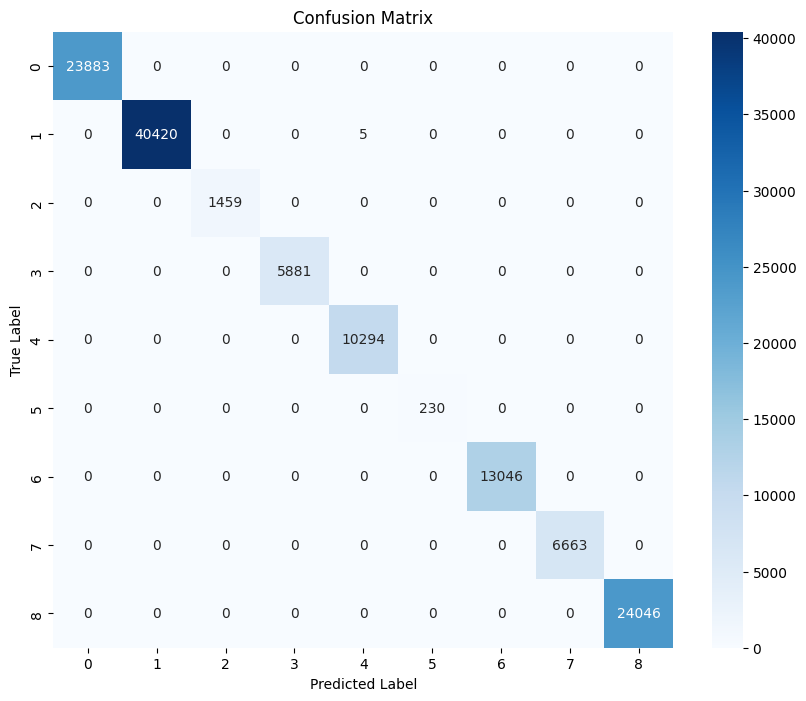

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

criterion =  'gini'
max_depth = None
min_samples_split = 10
min_samples_leaf = 2
max_features_list = None

dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
dt_classifier.fit(train, train_labels)

predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)


print("Accuracy of Decision Tree Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Dataset 3 DECISION TREE GMM
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components= 10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

criterion_list = ['gini', 'entropy']
max_depth_list = [None, 10]
min_samples_split_list = [5, 10]
min_samples_leaf_list = [1, 2]
max_features_list = ['auto',  None]


num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}


a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)

    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []


    for train_index, test_index in kf.split(train):

        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

2
3


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

4
5


...

28
29


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

30
31


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

32
Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}
Best accuracy: 0.9999583091278893


Accuracy of Decision Tree Classifier with GMM cluster labels: 0.999920588912624
Precision: 0.9999203449825154
Recall: 0.999920588912624
F1-score: 0.9999200141173663
Confusion Matrix:
 [[24001     0     0     0     0     0     0     0     0     0]
 [    0 50719     0     0     0     0     0     0     0     0]
 [    0     0  4117     0     0     0     0     0     0     0]
 [    0     0     0   229     0     1     0     0     0     0]
 [    0     0     0     0  5881     0     0     0     0     0]
 [    0     0     0     0     0  1459     0     0     0     0]
 [    0     0     0     0     0     0 23761     0     0     0]
 [    0     0     0     0     0     0     0  2546     0     0]
 [    0     0     0     0     0     0     0     0 12989     1]
 [    3     0     0     0     0     0     2     0     3   215]]


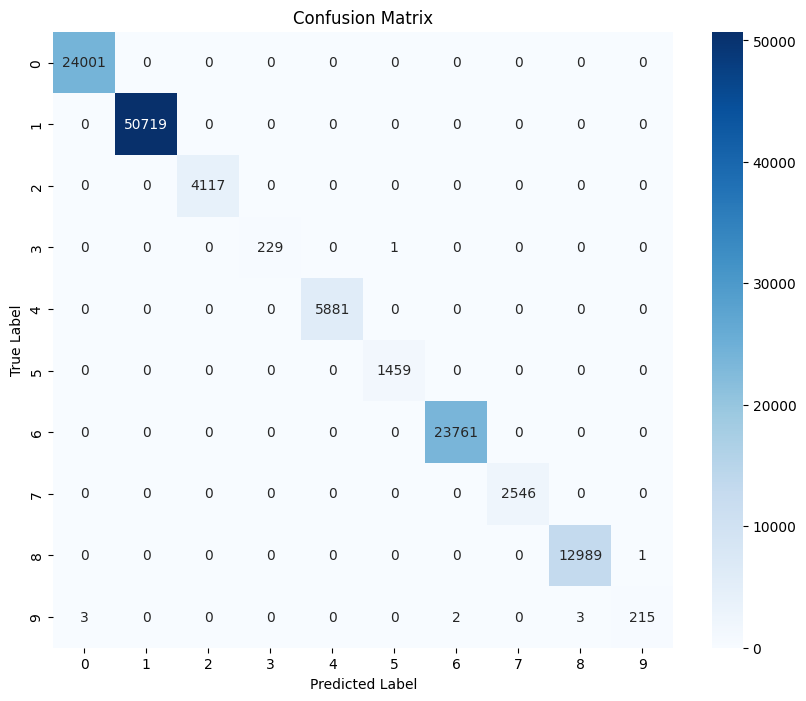

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression


n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

criterion =  'entropy'
max_depth = None
min_samples_split = 5
min_samples_leaf = 2
max_features_list = None

dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
dt_classifier.fit(train, train_labels)


predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)


print("Accuracy of Decision Tree Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Dataset 3 DECISION TREE K-Means
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import KMeans

k=10
init_type = 'k-means++'
max_iter=200


kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

criterion_list = ['gini', 'entropy']
max_depth_list = [None, 10]
min_samples_split_list = [5, 10]
min_samples_leaf_list = [1, 2]
max_features_list = ['auto',  None]


num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for criterion, max_depth, min_samples_split, min_samples_leaf, max_features in product(criterion_list, max_depth_list, min_samples_split_list, min_samples_leaf_list, max_features_list):
    a += 1
    print(a)


    dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    fold_accuracies = []


    for train_index, test_index in kf.split(train):

        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        dt_classifier.fit(train.iloc[train_index], train_labels)
        predictions = dt_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)


    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'criterion': criterion, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf, 'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skle

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

31


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skle

32


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
Best accuracy: 0.9999920589030861


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Decision Tree Classifier with K-means cluster labels: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
 [[24043     0     0     0     0     0     0     0     0     0]
 [    0 50719     0     0     0     0     0     0     0     0]
 [    0     0  4117     0     0     0     0     0     0     0]
 [    0     0     0   230     0     0     0     0     0     0]
 [    0     0     0     0  5881     0     0     0     0     0]
 [    0     0     0     0     0  1459     0     0     0     0]
 [    0     0     0     0     0     0 23883     0     0     0]
 [    0     0     0     0     0     0     0  2546     0     0]
 [    0     0     0     0     0     0     0     0 13046     0]
 [    0     0     0     0     0     0     0     0     0     3]]


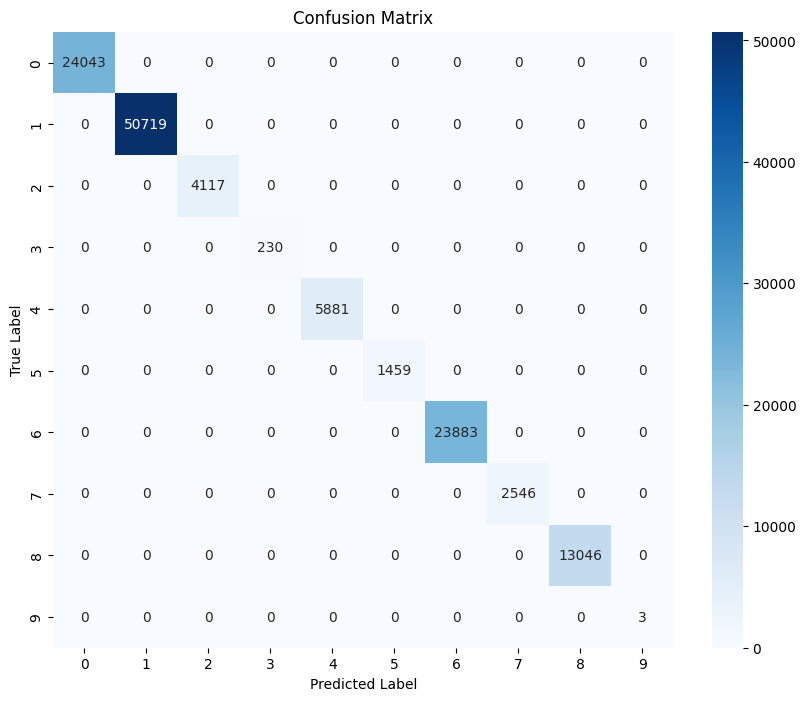

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=10
init_type = 'k-means++'
max_iter=200


kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)
train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

criterion =  'gini'
max_depth = None
min_samples_split = 5
min_samples_leaf = 1
max_features_list = None


dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
dt_classifier.fit(train, train_labels)


predictions = dt_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Decision Tree Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Dataset 3 RANDOM FOREST Minibatch K-Means
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)


n_estimators_list = [50, 100]
max_depth_list = [None, 5]
min_samples_split_list = [2, 5]
min_samples_leaf_list = [2, 4]
max_features_list = ['auto']

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a=0

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            for min_samples_leaf in min_samples_leaf_list:
                for max_features in max_features_list:
                    a=a+1
                    print(a)
                    rf_classifier = RandomForestClassifier(n_estimators=n_estimators,
                                                            max_depth=max_depth,
                                                            min_samples_split=min_samples_split,
                                                            min_samples_leaf=min_samples_leaf,
                                                            max_features=max_features,
                                                            random_state=42)
                    fold_accuracies = []


                    for train_index, test_index in kf.split(train):
                        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
                        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
                        rf_classifier.fit(train.iloc[train_index], train_labels)
                        predictions = rf_classifier.predict(train.iloc[test_index])
                        fold_accuracy = accuracy_score(test_labels, predictions)
                        fold_accuracies.append(fold_accuracy)
                    mean_accuracy = np.mean(fold_accuracies)
                    if mean_accuracy > best_accuracy:
                        best_accuracy = mean_accuracy
                        best_params = {'n_estimators': n_estimators,
                                       'max_depth': max_depth,
                                       'min_samples_split': min_samples_split,
                                       'min_samples_leaf': min_samples_leaf,
                                       'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

3


...

15


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

16


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past beha

Best hyperparameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'auto'}
Best accuracy: 1.0


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Accuracy of Logistic Regression Classifier with Minibatch K-means cluster labels: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
 [[137038      0      0      0      0      0      0      0      0]
 [     0  70765      0      0      0      0      0      0      0]
 [     0      0  20408      0      0      0      0      0      0]
 [     0      0      0  18762      0      0      0      0      0]
 [     0      0      0      0   4362      0      0      0      0]
 [     0      0      0      0      0  37937      0      0      0]
 [     0      0      0      0      0      0  41993      0      0]
 [     0      0      0      0      0      0      0   2607      0]
 [     0      0      0      0      0      0      0      0    698]]


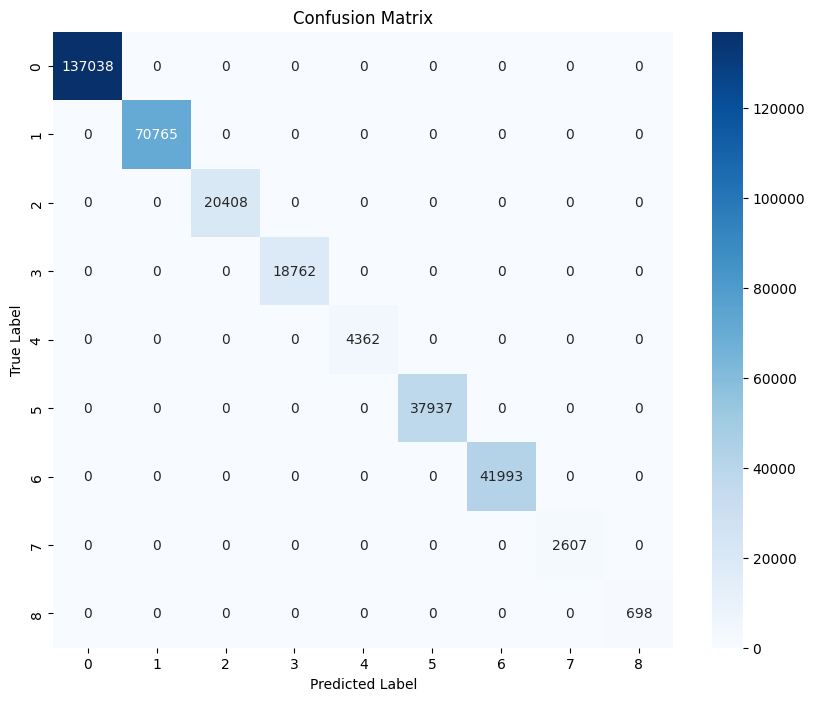

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans .fit_predict(train)
test_labels = minibatch_kmeans .predict(test)

n_estimators= 100
max_depth= 5
min_samples_split= 2
min_samples_leaf= 2
max_features='auto'

rf_classifier = RandomForestClassifier(n_estimators=n_estimators,
                                                            max_depth=max_depth,
                                                            min_samples_split=min_samples_split,
                                                            min_samples_leaf=min_samples_leaf,
                                                            max_features=max_features,
                                                            random_state=42)
rf_classifier.fit(train, train_labels)

predictions = rf_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)


print("Accuracy of Logistic Regression Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))


plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
